# Google Trends 1-year regression: search terms versus GP admissions

This notebook uses the one-year Google Trends search-term files in:

```text
Google_trends_v2/1y_data
```

The files are expected to have filenames beginning with `time_series_GB`. The predictive variable from each file is the **second source column**, regardless of its name. That selected second column is converted to a canonical `count` field inside the analysis code.

## Model

The default model treats the one-year Google Trends files as separate predictive variables:

```text
z(GP admissions)_t = beta_0 + beta_1 z(term 1)_t + beta_2 z(term 1)_{t-1} + beta_3 z(term 2)_t + ... + error_t
```

To check whether this is actually predictive, we use a chronological train-test split: fit on the earlier part of the time series, then evaluate predictions on the held-out later part.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt

from wastewater.io import find_repo_root
from wastewater.search_terms import (
    find_search_term_files,
    build_search_term_catalogue,
    search_file_to_long,
    build_search_term_regression_frame,
    search_term_lagged_predictor_columns,
    fit_search_term_ols,
    fit_search_term_train_test,
)
from wastewater.ukhsa import build_ukhsa_series_catalogue

ROOT = find_repo_root(ROOT)
PROCESSED = ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

SEARCH_TERMS_DIR = Path('Google_trends_v2') / '1y_data'
ROOT

PosixPath('/home/malachy/wastewater-pathogen-data')

## 1. Find one-year Google Trends files

This scans only `Google_trends_v2/1y_data` for files beginning with `time_series_GB`.

In [2]:
search_files = find_search_term_files(ROOT, search_dir=SEARCH_TERMS_DIR)
display(search_files.sort_values('path'))
print(f'Found {len(search_files)} one-year Google Trends files')

,path,filename,search_dir,suffix,size_kb
0,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1431_20260630-1431 (1)...,Google_trends_v2/1y_data,.csv,0.853516
1,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1431_20260630-1431.csv,Google_trends_v2/1y_data,.csv,0.842773
2,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432 (1)...,Google_trends_v2/1y_data,.csv,0.846680
3,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432 (2)...,Google_trends_v2/1y_data,.csv,0.849609
4,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432.csv,Google_trends_v2/1y_data,.csv,0.846680
5,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433 (1)...,Google_trends_v2/1y_data,.csv,0.842773
6,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433 (2)...,Google_trends_v2/1y_data,.csv,0.803711
7,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433.csv,Google_trends_v2/1y_data,.csv,0.848633
8,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1434_20260630-1434 (1)...,Google_trends_v2/1y_data,.csv,0.851562
9,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1434_20260630-1434 (2)...,Google_trends_v2/1y_data,.csv,0.845703


Found 26 one-year Google Trends files


## 2. Inspect selected predictor columns

The important check is the `predictor_column` column below. It should be the second source column in each one-year Google Trends file. Python uses zero-based indexing, so `VALUE_COLUMN_INDEX = 1` means the second column.

In [3]:
VALUE_COLUMN_INDEX = 1  # second source column

search_catalogue = build_search_term_catalogue(
    ROOT,
    search_dir=SEARCH_TERMS_DIR,
    value_column_index=VALUE_COLUMN_INDEX,
)
display(search_catalogue[['path', 'filename', 'date_column', 'predictor_column_index', 'predictor_column', 'usable_predictor_values', 'status', 'error']].sort_values('path'))

# Full column list for debugging.
display(search_catalogue[['path', 'columns']])

,path,filename,date_column,predictor_column_index,predictor_column,usable_predictor_values,status,error
0,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1431_20260630-1431 (1)...,time,1,persistent_cough,53,ok,
1,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1431_20260630-1431.csv,time,1,cough,53,ok,
2,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432 (1)...,time,1,dry_cough,53,ok,
3,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432 (2)...,time,1,chesty_cough,53,ok,
4,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1432_20260630-1432.csv,time,1,dry_cough,53,ok,
5,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433 (1)...,time,1,fever,53,ok,
6,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433 (2)...,time,1,high_temperature,53,ok,
7,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1433_20260630-1433.csv,time,1,sore_throat,53,ok,
8,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1434_20260630-1434 (1)...,time,1,breathlessness,53,ok,
9,Google_trends_v2/1y_data/time_series_GB_202506...,time_series_GB_20250630-1434_20260630-1434 (2)...,time,1,wheezing,53,ok,


,path,columns
0,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, persistent_cough]"
1,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, cough]"
2,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, dry_cough]"
3,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, chesty_cough]"
4,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, dry_cough]"
5,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, fever]"
6,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, high_temperature]"
7,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, sore_throat]"
8,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, breathlessness]"
9,Google_trends_v2/1y_data/time_series_GB_202506...,"[time, wheezing]"


## 3. Choose GP admissions outcome files

The outcome is taken from the UKHSA chart files classified as GP/admissions. If inference is wrong, manually set `OUTCOME_FILES` using paths from the catalogue.

In [4]:
ukhsa_catalogue = build_ukhsa_series_catalogue(ROOT)
display(ukhsa_catalogue[['path', 'filename', 'series_type', 'date_column', 'value_column']].sort_values(['series_type', 'path']))

SEARCH_FILES = search_catalogue.loc[search_catalogue['status'] == 'ok', 'path'].tolist()
OUTCOME_FILES = ukhsa_catalogue.loc[ukhsa_catalogue['series_type'] == 'gp_admissions', 'path'].tolist()

# Manual override examples:
# SEARCH_FILES = ['Google_trends_v2/1y_data/time_series_GB_...csv']
# OUTCOME_FILES = ['data/raw/ukhsa-chart-...gp-admissions...csv']

print('One-year Google Trends predictor files:')
for path in SEARCH_FILES:
    print(' -', path)

print('\nGP admissions outcome files:')
for path in OUTCOME_FILES:
    print(' -', path)

,path,filename,series_type,date_column,value_column
2,ukhsa-chart-Influenza-Hospital-Admissions-By-W...,ukhsa-chart-Influenza-Hospital-Admissions-By-W...,gp_admissions,date,metric_value
3,ukhsa-chart-Influenza-Like-Syndromic-Emergency...,ukhsa-chart-Influenza-Like-Syndromic-Emergency...,gp_admissions,date,metric_value
4,ukhsa-chart-Lower-Respiratory-Tract-Infection-...,ukhsa-chart-Lower-Respiratory-Tract-Infection-...,gp_admissions,date,metric_value
5,ukhsa-chart-Upper-Respiratory-Tract-Infection-...,ukhsa-chart-Upper-Respiratory-Tract-Infection-...,gp_admissions,date,metric_value
0,ukhsa-chart-Acute-Respiratory-Infection-NHS-11...,ukhsa-chart-Acute-Respiratory-Infection-NHS-11...,nhs_calls,date,metric_value
1,ukhsa-chart-Acute-Respiratory-Infection-Syndro...,ukhsa-chart-Acute-Respiratory-Infection-Syndro...,nhs_calls,date,metric_value


One-year Google Trends predictor files:
 - Google_trends_v2/1y_data/time_series_GB_20250630-1431_20260630-1431 (1).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1431_20260630-1431.csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432 (1).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432 (2).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432.csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1433_20260630-1433 (1).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1433_20260630-1433 (2).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1433_20260630-1433.csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1434_20260630-1434 (1).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1434_20260630-1434 (2).csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1434_20260630-1434.csv
 - Google_trends_v2/1y_data/time_series_GB_20250630-1435_20260630-1435 (1).csv
 - Google_trends_v2/1y_data/

## 4. Preview search-term second-column series

In [5]:
for path in SEARCH_FILES[:5]:
    print('\nSearch file:', path)
    display(search_file_to_long(ROOT, path, value_column_index=VALUE_COLUMN_INDEX).head())


Search file: Google_trends_v2/1y_data/time_series_GB_20250630-1431_20260630-1431 (1).csv


,date,search_term,count,source_file,date_column,value_column,value_column_index,week,month
0,2025-06-29,20250630 1431 20260630 1431 (1),37,Google_trends_v2/1y_data/time_series_GB_202506...,time,persistent_cough,1,2025-06-23,2025-06-01
1,2025-07-06,20250630 1431 20260630 1431 (1),27,Google_trends_v2/1y_data/time_series_GB_202506...,time,persistent_cough,1,2025-06-30,2025-07-01
2,2025-07-13,20250630 1431 20260630 1431 (1),31,Google_trends_v2/1y_data/time_series_GB_202506...,time,persistent_cough,1,2025-07-07,2025-07-01
3,2025-07-20,20250630 1431 20260630 1431 (1),35,Google_trends_v2/1y_data/time_series_GB_202506...,time,persistent_cough,1,2025-07-14,2025-07-01
4,2025-07-27,20250630 1431 20260630 1431 (1),34,Google_trends_v2/1y_data/time_series_GB_202506...,time,persistent_cough,1,2025-07-21,2025-07-01



Search file: Google_trends_v2/1y_data/time_series_GB_20250630-1431_20260630-1431.csv


,date,search_term,count,source_file,date_column,value_column,value_column_index,week,month
0,2025-06-29,20250630 1431 20260630 1431,31,Google_trends_v2/1y_data/time_series_GB_202506...,time,cough,1,2025-06-23,2025-06-01
1,2025-07-06,20250630 1431 20260630 1431,32,Google_trends_v2/1y_data/time_series_GB_202506...,time,cough,1,2025-06-30,2025-07-01
2,2025-07-13,20250630 1431 20260630 1431,33,Google_trends_v2/1y_data/time_series_GB_202506...,time,cough,1,2025-07-07,2025-07-01
3,2025-07-20,20250630 1431 20260630 1431,31,Google_trends_v2/1y_data/time_series_GB_202506...,time,cough,1,2025-07-14,2025-07-01
4,2025-07-27,20250630 1431 20260630 1431,31,Google_trends_v2/1y_data/time_series_GB_202506...,time,cough,1,2025-07-21,2025-07-01



Search file: Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432 (1).csv


,date,search_term,count,source_file,date_column,value_column,value_column_index,week,month
0,2025-06-29,20250630 1432 20260630 1432 (1),30,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-06-23,2025-06-01
1,2025-07-06,20250630 1432 20260630 1432 (1),35,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-06-30,2025-07-01
2,2025-07-13,20250630 1432 20260630 1432 (1),34,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-07,2025-07-01
3,2025-07-20,20250630 1432 20260630 1432 (1),28,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-14,2025-07-01
4,2025-07-27,20250630 1432 20260630 1432 (1),34,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-21,2025-07-01



Search file: Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432 (2).csv


,date,search_term,count,source_file,date_column,value_column,value_column_index,week,month
0,2025-06-29,20250630 1432 20260630 1432 (2),22,Google_trends_v2/1y_data/time_series_GB_202506...,time,chesty_cough,1,2025-06-23,2025-06-01
1,2025-07-06,20250630 1432 20260630 1432 (2),24,Google_trends_v2/1y_data/time_series_GB_202506...,time,chesty_cough,1,2025-06-30,2025-07-01
2,2025-07-13,20250630 1432 20260630 1432 (2),23,Google_trends_v2/1y_data/time_series_GB_202506...,time,chesty_cough,1,2025-07-07,2025-07-01
3,2025-07-20,20250630 1432 20260630 1432 (2),21,Google_trends_v2/1y_data/time_series_GB_202506...,time,chesty_cough,1,2025-07-14,2025-07-01
4,2025-07-27,20250630 1432 20260630 1432 (2),20,Google_trends_v2/1y_data/time_series_GB_202506...,time,chesty_cough,1,2025-07-21,2025-07-01



Search file: Google_trends_v2/1y_data/time_series_GB_20250630-1432_20260630-1432.csv


,date,search_term,count,source_file,date_column,value_column,value_column_index,week,month
0,2025-06-29,20250630 1432 20260630 1432,30,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-06-23,2025-06-01
1,2025-07-06,20250630 1432 20260630 1432,35,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-06-30,2025-07-01
2,2025-07-13,20250630 1432 20260630 1432,34,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-07,2025-07-01
3,2025-07-20,20250630 1432 20260630 1432,28,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-14,2025-07-01
4,2025-07-27,20250630 1432 20260630 1432,34,Google_trends_v2/1y_data/time_series_GB_202506...,time,dry_cough,1,2025-07-21,2025-07-01


## 5. Build regression frame

Use weekly aggregation first. Switch `FREQ = 'M'` if the search-term and GP-admission series are monthly. By default, each one-year Google Trends file is treated as a separate predictive variable.

In [6]:
FREQ = 'W'
LAGS = [0, 1, 2, 3, 4]
AGGREGATE_TERMS = False

regression_frame = build_search_term_regression_frame(
    ROOT,
    search_files=SEARCH_FILES,
    outcome_files=OUTCOME_FILES,
    search_dir=SEARCH_TERMS_DIR,
    freq=FREQ,
    lags=LAGS,
    aggregate_terms=AGGREGATE_TERMS,
    value_column_index=VALUE_COLUMN_INDEX,
)

display(regression_frame)

out = PROCESSED / 'google_trends_1y_gp_admissions_regression_frame.csv'
regression_frame.to_csv(out, index=False)
print(f'Saved {len(regression_frame):,} rows to {out.relative_to(ROOT)}')

/home/malachy/wastewater-pathogen-data/src/wastewater/search_terms.py:284: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[zcol] = standardise(frame[col])
/home/malachy/wastewater-pathogen-data/src/wastewater/search_terms.py:286: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[f"{zcol}_lag{lag}"] = frame[zcol].shift(lag)
/home/malachy/wastewater-pathogen-data/src/wastewater/search_terms.py:286: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

,period,20250630 1431 20260630 1431,20250630 1431 20260630 1431 (1),20250630 1432 20260630 1432,20250630 1432 20260630 1432 (1),20250630 1432 20260630 1432 (2),20250630 1433 20260630 1433,20250630 1433 20260630 1433 (1),20250630 1433 20260630 1433 (2),20250630 1434 20260630 1434,...,z_20250630_1438_20260630_1438_1_lag1,z_20250630_1438_20260630_1438_1_lag2,z_20250630_1438_20260630_1438_1_lag3,z_20250630_1438_20260630_1438_1_lag4,z_20250630_1439_20260630_1439,z_20250630_1439_20260630_1439_lag0,z_20250630_1439_20260630_1439_lag1,z_20250630_1439_20260630_1439_lag2,z_20250630_1439_20260630_1439_lag3,z_20250630_1439_20260630_1439_lag4
0,2025-06-23,31,37,30,30,22,51,64,4,48,...,NaN,NaN,NaN,NaN,-0.539628,-0.539628,NaN,NaN,NaN,NaN
1,2025-06-30,32,27,35,35,24,53,62,3,43,...,-0.904649,NaN,NaN,NaN,-1.038470,-1.038470,-0.539628,NaN,NaN,NaN
2,2025-07-07,33,31,34,34,23,52,56,3,47,...,-1.062195,-0.904649,NaN,NaN,-1.038470,-1.038470,-1.038470,-0.539628,NaN,NaN
3,2025-07-14,31,35,28,28,21,49,54,3,54,...,-1.324771,-1.062195,-0.904649,NaN,-0.761336,-0.761336,-1.038470,-1.038470,-0.539628,NaN
4,2025-07-21,31,34,34,34,20,52,49,2,48,...,-1.272255,-1.324771,-1.062195,-0.904649,-1.537312,-1.537312,-0.761336,-1.038470,-1.038470,-0.539628
5,2025-07-28,31,23,35,35,20,52,54,2,45,...,-1.167225,-1.272255,-1.324771,-1.062195,-1.315605,-1.315605,-1.537312,-0.761336,-1.038470,-1.038470
6,2025-08-04,32,43,34,34,21,50,51,4,49,...,-1.324771,-1.167225,-1.272255,-1.324771,-1.537312,-1.537312,-1.315605,-1.537312,-0.761336,-1.038470
7,2025-08-11,30,35,32,32,18,51,47,2,45,...,-1.062195,-1.324771,-1.167225,-1.272255,-1.093897,-1.093897,-1.537312,-1.315605,-1.537312,-0.761336
8,2025-08-18,32,44,31,31,22,52,52,2,46,...,-1.062195,-1.062195,-1.324771,-1.167225,-1.038470,-1.038470,-1.093897,-1.537312,-1.315605,-1.537312
9,2025-08-25,36,37,32,32,21,50,49,2,54,...,-1.377286,-1.062195,-1.062195,-1.324771,-1.648166,-1.648166,-1.038470,-1.093897,-1.537312,-1.315605


Saved 53 rows to data/processed/google_trends_1y_gp_admissions_regression_frame.csv


## 6. Plot aligned series

For visualisation, this computes the mean z-score across the unlagged Google Trends predictors and plots it against GP admissions. The regression itself uses the individual lagged predictor columns.

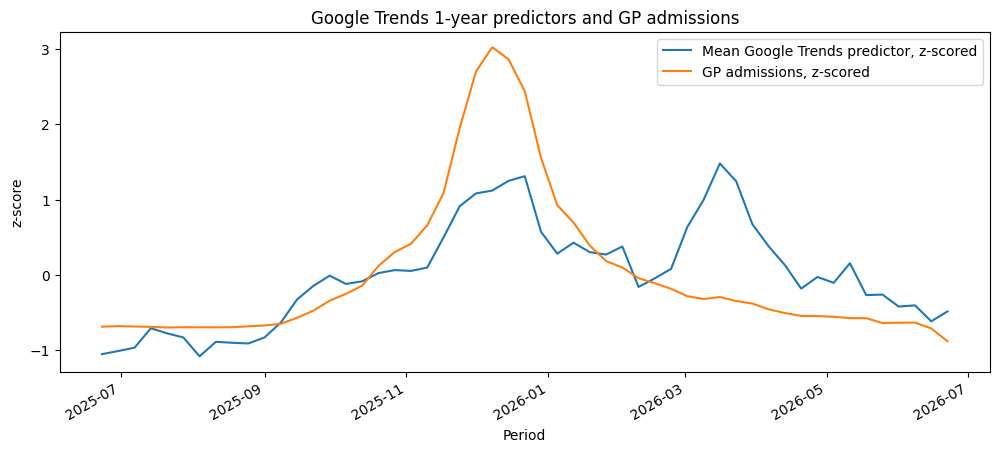

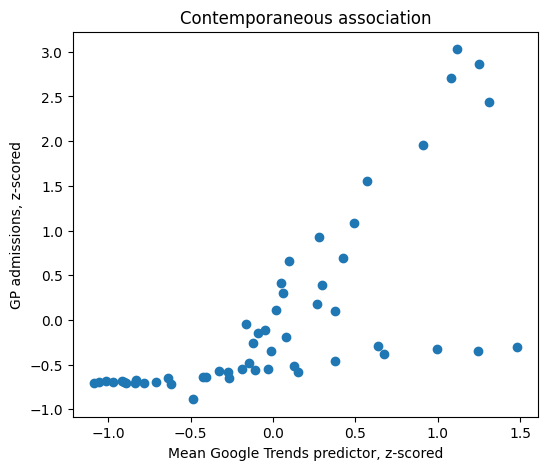

In [7]:
unlagged_search_cols = [
    col for col in regression_frame.columns
    if col.startswith('z_') and '_lag' not in col and col != 'z_gp_admissions'
]

plot_df = regression_frame.copy()
if AGGREGATE_TERMS:
    plot_df['z_mean_google_trends'] = plot_df['z_search_count']
else:
    plot_df['z_mean_google_trends'] = plot_df[unlagged_search_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df['period'], plot_df['z_mean_google_trends'], label='Mean Google Trends predictor, z-scored')
ax.plot(plot_df['period'], plot_df['z_gp_admissions'], label='GP admissions, z-scored')
ax.set_title('Google Trends 1-year predictors and GP admissions')
ax.set_xlabel('Period')
ax.set_ylabel('z-score')
ax.legend()
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(plot_df['z_mean_google_trends'], plot_df['z_gp_admissions'])
ax.set_xlabel('Mean Google Trends predictor, z-scored')
ax.set_ylabel('GP admissions, z-scored')
ax.set_title('Contemporaneous association')
plt.show()

## 7. Choose predictors and check model size

For one-year data, it is easy to have too many lagged predictors relative to the number of observations. If the number of complete observations is close to the number of predictors, reduce `LAGS`, use `AGGREGATE_TERMS = True`, or switch to a regularised model.

In [8]:
SEASONAL_CONTROLS = False

if AGGREGATE_TERMS:
    predictor_cols = [f'z_search_count_lag{lag}' for lag in LAGS]
else:
    predictor_cols = search_term_lagged_predictor_columns(regression_frame, lags=LAGS)

complete_rows = regression_frame[['z_gp_admissions', *predictor_cols]].dropna().shape[0]
print(f'Complete rows available after lagging: {complete_rows}')
print(f'Lagged Google Trends predictor columns: {len(predictor_cols)}')

if complete_rows <= len(predictor_cols) + 2:
    print('WARNING: predictors are numerous relative to observations. Train-test performance may be unstable; consider fewer lags or aggregate terms.')

print(predictor_cols)

Complete rows available after lagging: 49
Lagged Google Trends predictor columns: 130
['z_20250630_1431_20260630_1431_1_lag0', 'z_20250630_1431_20260630_1431_1_lag1', 'z_20250630_1431_20260630_1431_1_lag2', 'z_20250630_1431_20260630_1431_1_lag3', 'z_20250630_1431_20260630_1431_1_lag4', 'z_20250630_1431_20260630_1431_lag0', 'z_20250630_1431_20260630_1431_lag1', 'z_20250630_1431_20260630_1431_lag2', 'z_20250630_1431_20260630_1431_lag3', 'z_20250630_1431_20260630_1431_lag4', 'z_20250630_1432_20260630_1432_1_lag0', 'z_20250630_1432_20260630_1432_1_lag1', 'z_20250630_1432_20260630_1432_1_lag2', 'z_20250630_1432_20260630_1432_1_lag3', 'z_20250630_1432_20260630_1432_1_lag4', 'z_20250630_1432_20260630_1432_2_lag0', 'z_20250630_1432_20260630_1432_2_lag1', 'z_20250630_1432_20260630_1432_2_lag2', 'z_20250630_1432_20260630_1432_2_lag3', 'z_20250630_1432_20260630_1432_2_lag4', 'z_20250630_1432_20260630_1432_lag0', 'z_20250630_1432_20260630_1432_lag1', 'z_20250630_1432_20260630_1432_lag2', 'z_202506

## 8. Full-sample fit

This is useful for inspection, but it is **not** evidence of predictive performance because it uses all available periods. The train-test section below is the predictive check.

In [9]:
full_sample_result = fit_search_term_ols(
    regression_frame,
    lags=LAGS,
    predictor_columns=predictor_cols,
    seasonal_controls=SEASONAL_CONTROLS,
)
print(full_sample_result.summary())

                            OLS Regression Results                            
Dep. Variable:        z_gp_admissions   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                 2.599e+30
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                nan
Time:                        16:43:42   Log-Likelihood:                 1523.3
No. Observations:                  49   AIC:                            -2949.
Df Residuals:                       0   BIC:                            -2856.
Df Model:                          48                                         
Covariance Type:                  HAC                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 130, but rank is 49
  warnings.warn('covariance of constraints does not have full '


## 9. Chronological train-test split

This fits the model on the earlier part of the series and evaluates predictions on the final held-out periods. This is the main check of whether the Google Trends model is predictive.

In [10]:
TRAIN_FRACTION = 0.8
MIN_TEST_SIZE = 4

tt = fit_search_term_train_test(
    regression_frame,
    predictor_columns=predictor_cols,
    lags=LAGS,
    train_fraction=TRAIN_FRACTION,
    min_test_size=MIN_TEST_SIZE,
    seasonal_controls=SEASONAL_CONTROLS,
)

metrics = pd.DataFrame([tt['metrics']])
display(metrics)

print(tt['model'].summary())

train_rows = tt['train']
test_rows = tt['test']
all_rows = pd.concat([train_rows, test_rows], ignore_index=True)

out = PROCESSED / 'google_trends_1y_gp_admissions_train_test_predictions.csv'
all_rows.to_csv(out, index=False)
print(f'Saved train/test predictions to {out.relative_to(ROOT)}')

,n_test,mae,rmse,r2,correlation,baseline_rmse,mse_skill_vs_train_mean
0,10.0,0.224956,0.248005,-5.408275,0.281534,0.873694,0.919424


                            OLS Regression Results                            
Dep. Variable:        z_gp_admissions   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                 5.700e+29
Date:                Wed, 01 Jul 2026   Prob (F-statistic):                nan
Time:                        16:43:43   Log-Likelihood:                 1208.3
No. Observations:                  39   AIC:                            -2339.
Df Residuals:                       0   BIC:                            -2274.
Df Model:                          38                                         
Covariance Type:                  HAC                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/malachy/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 130, but rank is 39
  warnings.warn('covariance of constraints does not have full '


## 10. Plot held-out predictions

The shaded-style split is shown by plotting training and test predictions separately. The test-period fit is the relevant predictive result.

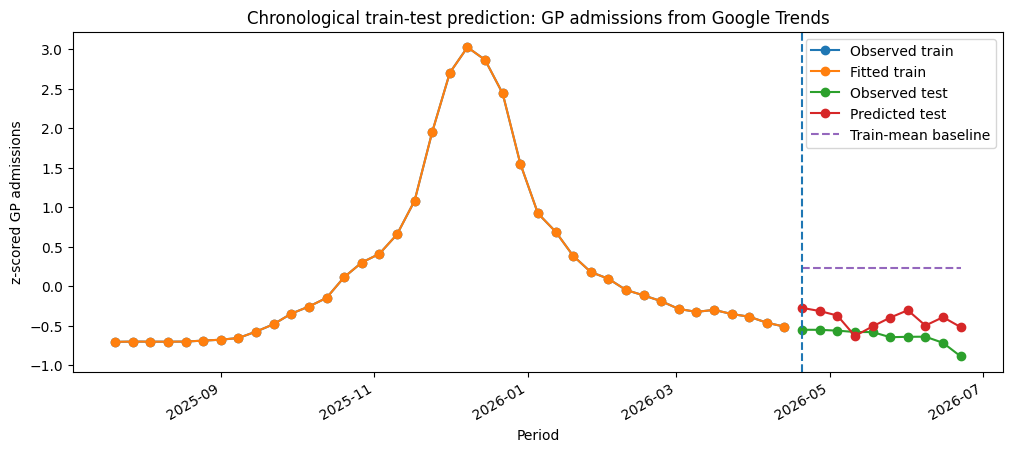

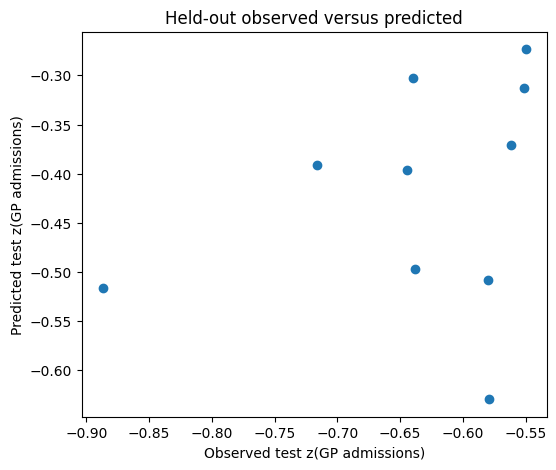

,period,z_gp_admissions,prediction,baseline_prediction,residual
43,2026-04-20,-0.550058,-0.273399,0.233574,-0.276659
44,2026-04-27,-0.551204,-0.313028,0.233574,-0.238176
45,2026-05-04,-0.561343,-0.370361,0.233574,-0.190982
46,2026-05-11,-0.578841,-0.629449,0.233574,0.050608
47,2026-05-18,-0.579613,-0.507797,0.233574,-0.071816
48,2026-05-25,-0.644649,-0.396306,0.233574,-0.248343
49,2026-06-01,-0.639553,-0.303043,0.233574,-0.336510
50,2026-06-08,-0.638094,-0.496951,0.233574,-0.141144
51,2026-06-15,-0.715888,-0.390944,0.233574,-0.324943
52,2026-06-22,-0.886856,-0.516474,0.233574,-0.370381


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_rows['period'], train_rows['z_gp_admissions'], label='Observed train', marker='o')
ax.plot(train_rows['period'], train_rows['prediction'], label='Fitted train', marker='o')
ax.plot(test_rows['period'], test_rows['z_gp_admissions'], label='Observed test', marker='o')
ax.plot(test_rows['period'], test_rows['prediction'], label='Predicted test', marker='o')
ax.plot(test_rows['period'], test_rows['baseline_prediction'], label='Train-mean baseline', linestyle='--')
ax.axvline(test_rows['period'].min(), linestyle='--')
ax.set_title('Chronological train-test prediction: GP admissions from Google Trends')
ax.set_xlabel('Period')
ax.set_ylabel('z-scored GP admissions')
ax.legend()
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_rows['z_gp_admissions'], test_rows['prediction'])
ax.set_xlabel('Observed test z(GP admissions)')
ax.set_ylabel('Predicted test z(GP admissions)')
ax.set_title('Held-out observed versus predicted')
plt.show()

display(test_rows[['period', 'z_gp_admissions', 'prediction', 'baseline_prediction', 'residual']])

## 11. Interpretation

Important checks:

- `rmse` should be lower than `baseline_rmse`.
- `mse_skill_vs_train_mean` should be positive. Values below zero mean the model is worse than simply predicting the training-period mean.
- Held-out predictions should track the direction and timing of GP admissions, not just fit the training data.
- With only one year of data, test estimates can be noisy. Treat this as an initial predictive screen, not a final validation.